# Formação de Pares — Método da Cointegração (Rad et al., 2016)

Implementa a **fase de formação** via cointegração de Engle-Granger.

Para cada janela rolante de formação:
1. Filtra ativos com dados **completos** no período
2. Normaliza preços: `Q_i(t) = P_i(t) / P_i(0)`
3. (Opcional) Pré-filtra os N pares de **menor SSD** como candidatos — reduz custo computacional
4. Para cada candidato, testa **cointegração por Engle-Granger dois passos**:
   - **Passo 1** — OLS: `Q2 = α + β·Q1 + ε`
   - **Passo 2** — teste de estacionariedade do resíduo `ε`, configurável via `METODO_COINT`:
     - `"ADF"` — Augmented Dickey-Fuller; cointegrado se `ADF < −3.34` (MacKinnon 5%)
     - `"CRDW"` — Cointegrating Regression Durbin-Watson (Engle-Granger 1987); cointegrado se `DW > crit(T)`, com o valor crítico reescalado pelo tamanho de amostra (`0.386 × 100/T`, ≈0.153 para T≈252). Ver nota abaixo.
5. Seleciona os **top-20 pares cointegrados** de menor SSD
6. Salva `β`, `α`, média e desvio do spread para uso na fase de negociação

**Direção do teste — sempre bilateral:** as duas direções (`Q2~Q1` e `Q1~Q2`) são testadas e o par só é aprovado se **ambas** rejeitarem a raiz unitária; salvam-se os parâmetros da direção **mais fortemente estacionária**. Isso elimina a sensibilidade arbitrária à ordenação da regressão — nenhum par entra no portfólio por acidente de qual ativo foi posto como variável dependente. A coluna `direcao` registra qual orientação foi salva (`B~A` ou `A~B`) e é lida pelo notebook de negociação.

> **Valor crítico do CRDW e dados diários.** O CRDW é `DW ≈ 2(1−ρ₁)`. Em frequência diária os spreads são muito persistentes (`ρ₁≈1`), então o DW é naturalmente baixo mesmo para pares cointegrados. O valor de tabela de Engle-Granger (1987), **0.386**, é calibrado para `T≈100` e exigiria meia-vida de reversão de ~3 dias — rejeitando quase tudo. Como a distribuição nula do CRDW escala com `1/T`, reescalamos: `crit(T) = 0.386 × 100/T`. Para a janela de 12 meses (`T≈252`) isso dá ≈0.153.

> Comparação lado a lado dos quatro cenários (ADF/CRDW × uni/bilateral): ver `comparacao_adf_crdw.ipynb`.

**Referência:** Rad, H., Low, R.K.Y. & Faff, R. (2016). *The profitability of pairs trading strategies: distance, cointegration and copula methods.* Quantitative Finance, 16(10), 1541–1558.

In [1]:
import re
import warnings
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson

warnings.filterwarnings('ignore')

# ── Janela rolante ────────────────────────────────────────────────────────────
MESES_FORMACAO   = 12  # duração do período de formação (meses)
MESES_NEGOCIACAO = 6   # duração do período de negociação (meses)
PASSO_MESES      = 1   # avanço da janela a cada iteração
                       #   6 → semestral, ~69 janelas (= ritmo do método da distância)
                       #   1 → mensal, ~400 janelas (= Rad et al.)

# ── Pré-filtro por distância SSD ─────────────────────────────────────────────
SSD_PRE_FILTER_N = 100  # testa cointegração apenas nos N pares de menor SSD
                        # None → testa todos os pares válidos
                        

# ── Seleção de pares ──────────────────────────────────────────────────────────
TOP_K_COINT     = 20    # máximo de pares cointegrados por janela
SSD_MIN         = 0.01  # descarta ghost tickers (SSD ≈ 0)

# ── Teste de cointegração ─────────────────────────────────────────────────────
METODO_COINT = "ADF"    # "ADF"  → Augmented Dickey-Fuller (MacKinnon)
                        # "CRDW" → Cointegrating Regression Durbin-Watson (Engle-Granger 1987)
                        # O teste é sempre BILATERAL: as duas direções (Q2~Q1 e Q1~Q2)
                        # precisam passar, e salva-se a mais fortemente estacionária.

CRIT_COINT_5PCT = -3.34 # ADF: MacKinnon 5% para resíduo de regressão de cointegração (2 variáveis)
                        #      cointegrado se stat < CRIT_COINT_5PCT (muito negativo)

# CRDW: o valor crítico depende do tamanho de amostra T. A tabela de Engle-Granger
# (1987) dá 0.386 a 5% para T≈100. Como a distribuição nula do CRDW escala com 1/T
# (DW = Σ(Δε)²/Σε² ~ O(T)/O(T²)), reescalamos o valor crítico para a janela real:
#       crit(T) = CRDW_CRIT_REF_T100 × 100 / T
# Para T≈252 (12 meses) → ≈0.153. Aplicar 0.386 direto a dados diários rejeitaria
# quase tudo: spreads diários são persistentes (ρ₁≈1) → DW naturalmente baixo.
CRDW_CRIT_REF_T100 = 0.386

META_COLS = ['year', 'semester', 'period', 'day_in_semester', 'total_days_sem']

## 1. Carregando os dados

In [2]:
df = pd.read_csv('../../data_bases/base_unificada.csv', parse_dates=['date'])
df = df.set_index('date')

colunas_preco = [c for c in df.columns if c not in META_COLS]

print(f"Dias de pregão:          {df.shape[0]}")
print(f"Ativos no universo total: {len(colunas_preco)}")
print(f"Período: {df.index[0].date()} até {df.index[-1].date()}")

Dias de pregão:          8939
Ativos no universo total: 1343
Período: 1990-07-03 até 2025-12-31


## 2. Construindo as janelas temporais

As janelas são definidas em **meses calendário**, o que permite PASSO_MESES = 1 (mensal, como Rad et al.) ou PASSO_MESES = 6 (semestral, como o método da distância).

In [3]:
# Índice de mês para cada dia de pregão — calculado uma vez para uso no loop
meses_por_linha = pd.PeriodIndex(df.index, freq='M')
meses_unicos    = sorted(meses_por_linha.unique())

n_janelas = max(0, (len(meses_unicos) - MESES_FORMACAO - MESES_NEGOCIACAO) // PASSO_MESES + 1)

print(f"Meses disponíveis: {len(meses_unicos)}")
print(f"Primeiro: {meses_unicos[0]} | Último: {meses_unicos[-1]}")
print(f"Janelas a processar: {n_janelas}")
print()

ex_form = meses_unicos[:MESES_FORMACAO]
ex_neg  = meses_unicos[MESES_FORMACAO : MESES_FORMACAO + MESES_NEGOCIACAO]
print(f"Exemplo — 1ª janela:")
print(f"  Formação:   {ex_form[0]} → {ex_form[-1]}")
print(f"  Negociação: {ex_neg[0]} → {ex_neg[-1]}")

Meses disponíveis: 426
Primeiro: 1990-07 | Último: 2025-12
Janelas a processar: 409

Exemplo — 1ª janela:
  Formação:   1990-07 → 1991-06
  Negociação: 1991-07 → 1991-12


## 3. Funções

In [4]:
def filtrar_ativos_completos(precos):
    """Remove ativos com qualquer dado faltante no período."""
    return precos.dropna(axis=1, how='any')


def normalizar_precos(precos):
    """Q_i(t) = P_i(t) / P_i(0): todos os ativos partem de 1."""
    return precos.div(precos.iloc[0])


def calcular_ssd(Q):
    """D(i,j) = Σ_t (Q_i - Q_j)² via álgebra matricial."""
    arr   = Q.values
    G     = arr.T @ arr
    norms = np.diag(G)
    ssd   = norms[:, None] + norms[None, :] - 2 * G
    return pd.DataFrame(ssd, index=Q.columns, columns=Q.columns)


def mesmo_emissor(ticker1, ticker2):
    """True se os dois tickers são classes do mesmo emissor (ex: GOOGL/GOOG, FOXA/FOX)."""
    def base(t):
        t = re.sub(r'[._][A-Z]$', '', t)
        if len(t) > 2 and t[-1] in 'ABCKL':
            t = t[:-1]
        return t
    return base(ticker1) == base(ticker2)


def selecionar_candidatos_ssd(ssd_df, n=None):
    """
    Retorna lista de (ativo1, ativo2, ssd) ordenada por SSD crescente.
    Exclui ghost tickers (SSD < SSD_MIN) e pares do mesmo emissor.
    n=None retorna todos os pares válidos.
    """
    tickers = ssd_df.columns.tolist()
    i_idx, j_idx = np.triu_indices(len(tickers), k=1)
    ssds = ssd_df.values[i_idx, j_idx]

    validos = np.array([
        k for k in range(len(i_idx))
        if ssds[k] >= SSD_MIN and not mesmo_emissor(tickers[i_idx[k]], tickers[j_idx[k]])
    ])

    if len(validos) == 0:
        return []

    i_idx, j_idx, ssds = i_idx[validos], j_idx[validos], ssds[validos]
    order = np.argsort(ssds)
    i_idx, j_idx, ssds = i_idx[order], j_idx[order], ssds[order]

    if n is not None:
        i_idx, j_idx, ssds = i_idx[:n], j_idx[:n], ssds[:n]

    return [(tickers[i_idx[k]], tickers[j_idx[k]], float(ssds[k])) for k in range(len(i_idx))]


# ──────────────────────────────────────────────────────────────────────────────
# Teste de cointegração — ADF ou CRDW, sempre bilateral
# ──────────────────────────────────────────────────────────────────────────────

def _ols_residuo(y_arr, x_arr):
    """OLS com intercepto: y = alpha + beta·x + resíduo. Retorna (alpha, beta, resíduo)."""
    X      = sm.add_constant(x_arr, has_constant='add')
    model  = sm.OLS(y_arr, X).fit()
    params = np.asarray(model.params)         # [constante, coef_x]
    return float(params[0]), float(params[1]), model.resid


def crit_crdw(T):
    """
    Valor crítico do CRDW a 5%, reescalado para o tamanho de amostra T.
    crit(T) = CRDW_CRIT_REF_T100 × 100 / T   (a distribuição nula do CRDW ~ O(1/T)).
    Ex.: T=252 → ≈0.153; T=100 → 0.386 (valor de tabela Engle-Granger 1987).
    """
    return CRDW_CRIT_REF_T100 * 100.0 / T


def _estatistica_residuo(residuo, metodo):
    """
    Calcula a estatística de estacionariedade do resíduo e decide se passa.

    ADF  — Augmented Dickey-Fuller. regression='n' (sem constante): o resíduo do
           OLS com intercepto já tem média zero por construção, o que é a
           especificação consistente com o valor crítico de MacKinnon (-3.34).
           Mais negativo = mais estacionário → passa se stat < CRIT_COINT_5PCT.
    CRDW — Cointegrating Regression Durbin-Watson (Engle-Granger 1987).
           DW ≈ 2·(1 − ρ): resíduo estacionário → DW longe de zero.
           Maior = mais estacionário → passa se stat > crit_crdw(T), com o valor
           crítico reescalado pelo tamanho de amostra T (ver crit_crdw).
    """
    if metodo == "ADF":
        stat   = adfuller(residuo, autolag='AIC', regression='n')[0]
        passou = stat < CRIT_COINT_5PCT
    elif metodo == "CRDW":
        stat   = durbin_watson(residuo)
        passou = stat > crit_crdw(len(residuo))
    else:
        raise ValueError(f"Método de cointegração desconhecido: {metodo!r} (use 'ADF' ou 'CRDW')")
    return stat, passou


def testar_cointegracao(q_a, q_b, metodo=None):
    """
    Engle-Granger dois passos com escolha de teste (ADF/CRDW). O teste é sempre
    BILATERAL: as duas direções da regressão são estimadas e o par só é aprovado
    se AMBAS rejeitarem a raiz unitária.

    q_a, q_b   : séries normalizadas Q dos ativos A (=ativo1) e B (=ativo2).
    metodo     : "ADF" ou "CRDW" (default: METODO_COINT).

    Convenção de direção (qual é a variável dependente do OLS):
        'B~A' → y=Q_b, x=Q_a → spread = Q_b - alpha - beta·Q_a   (orientação original)
        'A~B' → y=Q_a, x=Q_b → spread = Q_a - alpha - beta·Q_b

    Aprovado nas duas direções, salvam-se os parâmetros da direção mais fortemente
    estacionária — assim o resultado não depende de qual ativo foi arbitrariamente
    posto como variável dependente.

    Retorna dict:
        cointegrado, beta, alpha, spread_media, spread_desvio, stat, direcao
    """
    if metodo is None:
        metodo = METODO_COINT

    a_arr = np.asarray(q_a, dtype=float)
    b_arr = np.asarray(q_b, dtype=float)

    falha = {'cointegrado': False, 'beta': np.nan, 'alpha': np.nan,
             'spread_media': np.nan, 'spread_desvio': np.nan,
             'stat': np.nan, 'direcao': None}

    # Série constante (variância zero) → regressão degenerada
    if a_arr.std() < 1e-10 or b_arr.std() < 1e-10:
        return falha

    # Direção 1: B ~ A  (y=Q_b, x=Q_a) — orientação original
    alpha1, beta1, resid1 = _ols_residuo(b_arr, a_arr)
    stat1, passou1        = _estatistica_residuo(resid1, metodo)

    def _resultado(alpha, beta, resid, stat, direcao):
        return {'cointegrado': True, 'beta': beta, 'alpha': alpha,
                'spread_media': float(resid.mean()), 'spread_desvio': float(resid.std()),
                'stat': float(stat), 'direcao': direcao}

    # Direção 2: A ~ B  (y=Q_a, x=Q_b)
    alpha2, beta2, resid2 = _ols_residuo(a_arr, b_arr)
    stat2, passou2        = _estatistica_residuo(resid2, metodo)

    if not (passou1 and passou2):
        return falha

    # Aprovado nas duas direções: salva a mais fortemente estacionária
    if metodo == "ADF":
        escolhe_1 = stat1 <= stat2   # ADF: mais negativo = mais forte
    else:                            # CRDW: maior DW = mais forte
        escolhe_1 = stat1 >= stat2

    if escolhe_1:
        return _resultado(alpha1, beta1, resid1, stat1, 'B~A')
    return _resultado(alpha2, beta2, resid2, stat2, 'A~B')

## 4. Processando todas as janelas de formação

Para cada janela:
- Calcula SSD de todos os pares e seleciona os `SSD_PRE_FILTER_N` candidatos de menor distância
- Testa cointegração (Engle-Granger) em ordem de SSD crescente
- Para quando atingir `TOP_K_COINT` pares cointegrados

In [5]:
resultados = []

fim = len(meses_unicos) - MESES_FORMACAO - MESES_NEGOCIACAO + 1

print(f"Teste de cointegração: {METODO_COINT} | bilateral (ambas as direções)\n")

for i in range(0, fim, PASSO_MESES):

    meses_form = meses_unicos[i : i + MESES_FORMACAO]
    meses_neg  = meses_unicos[i + MESES_FORMACAO : i + MESES_FORMACAO + MESES_NEGOCIACAO]

    form_inicio = str(meses_form[0])
    form_fim    = str(meses_form[-1])
    neg_inicio  = str(meses_neg[0])
    neg_fim     = str(meses_neg[-1])
    janela_id   = f"{form_inicio}_a_{form_fim}"

    # Dados do período de formação
    mask   = meses_por_linha.isin(meses_form)
    precos = filtrar_ativos_completos(df.loc[mask, colunas_preco])

    if precos.shape[1] < 2:
        print(f"{janela_id}: sem ativos suficientes, pulando.")
        continue

    Q = normalizar_precos(precos)

    # Candidatos ordenados por SSD crescente
    ssd_df     = calcular_ssd(Q)
    candidatos = selecionar_candidatos_ssd(ssd_df, SSD_PRE_FILTER_N)

    # Testa cointegração em ordem de SSD crescente; para ao atingir TOP_K_COINT
    pares_coint = []
    for ativo1, ativo2, ssd_val in candidatos:
        res = testar_cointegracao(Q[ativo1].values, Q[ativo2].values)
        if res['cointegrado']:
            pares_coint.append({
                'ativo1':        ativo1,
                'ativo2':        ativo2,
                'ssd':           ssd_val,
                'beta':          res['beta'],
                'alpha':         res['alpha'],
                'spread_media':  res['spread_media'],
                'spread_desvio': res['spread_desvio'],
                'stat':          res['stat'],
                'direcao':       res['direcao'],
                'metodo':        METODO_COINT,
            })
            if len(pares_coint) >= TOP_K_COINT:
                break

    for rank, par in enumerate(pares_coint, 1):
        resultados.append({
            'janela':            janela_id,
            'formacao_inicio':   form_inicio,
            'formacao_fim':      form_fim,
            'negociacao_inicio': neg_inicio,
            'negociacao_fim':    neg_fim,
            'rank':              rank,
            **par,
        })

    print(
        f"{janela_id}: {precos.shape[1]:3d} ativos | "
        f"{len(candidatos):4d} testados | "
        f"{len(pares_coint):2d} cointegrados"
    )

Teste de cointegração: ADF | bilateral (ambas as direções)

1990-07_a_1991-06: 690 ativos |  100 testados | 20 cointegrados
1990-08_a_1991-07: 691 ativos |  100 testados | 20 cointegrados
1990-09_a_1991-08: 690 ativos |  100 testados | 20 cointegrados
1990-10_a_1991-09: 690 ativos |  100 testados | 20 cointegrados
1990-11_a_1991-10: 690 ativos |  100 testados | 20 cointegrados
1990-12_a_1991-11: 689 ativos |  100 testados | 20 cointegrados
1991-01_a_1991-12: 690 ativos |  100 testados | 20 cointegrados
1991-02_a_1992-01: 691 ativos |  100 testados | 20 cointegrados
1991-03_a_1992-02: 692 ativos |  100 testados | 20 cointegrados
1991-04_a_1992-03: 695 ativos |  100 testados | 20 cointegrados
1991-05_a_1992-04: 699 ativos |  100 testados | 20 cointegrados
1991-06_a_1992-05: 702 ativos |  100 testados | 20 cointegrados
1991-07_a_1992-06: 704 ativos |  100 testados | 20 cointegrados
1991-08_a_1992-07: 707 ativos |  100 testados | 20 cointegrados
1991-09_a_1992-08: 708 ativos |  100 testado

## 5. Resultados

In [6]:
pares_df = pd.DataFrame(resultados)

n_janelas_ok    = pares_df['janela'].nunique()
media_por_janela = len(pares_df) / n_janelas_ok
pct_cheias      = (pares_df.groupby('janela')['rank'].max() >= TOP_K_COINT).mean()

print(f"Método (sempre bilateral):    {METODO_COINT}")
print(f"Janelas processadas:          {n_janelas_ok}")
print(f"Pares registrados:            {len(pares_df)}")
print(f"Pares por janela (média):     {media_por_janela:.1f}")
print(f"Janelas com {TOP_K_COINT} pares cheios:   {pct_cheias:.1%}")
print(f"Estatística média ({METODO_COINT}):     {pares_df['stat'].mean():.3f}")
print(f"Direção salva — B~A: {(pares_df['direcao'] == 'B~A').mean():.1%} | "
      f"A~B: {(pares_df['direcao'] == 'A~B').mean():.1%}")

pares_df.head(10)

Método (sempre bilateral):    ADF
Janelas processadas:          409
Pares registrados:            8147
Pares por janela (média):     19.9
Janelas com 20 pares cheios:   97.6%
Estatística média (ADF):     -4.657
Direção salva — B~A: 50.8% | A~B: 49.2%


,janela,formacao_inicio,formacao_fim,negociacao_inicio,negociacao_fim,rank,ativo1,ativo2,ssd,beta,alpha,spread_media,spread_desvio,stat,direcao,metodo
0,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,1,GPUI,FPC,0.080954,0.940949,0.066557,1.265035e-15,0.017136,-4.620601,A~B,ADF
1,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,2,FPC,ES,0.097991,0.842708,0.162217,3.140472e-17,0.014277,-6.092363,B~A,ADF
2,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,3,45200Q,CNP,0.101924,0.947739,0.058186,-1.004951e-15,0.019684,-4.535409,B~A,ADF
3,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,4,SCG,WEC,0.103967,0.948112,0.060765,3.815452e-15,0.019458,-4.195185,B~A,ADF
4,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,5,PEG,0961514D,0.104052,0.989430,0.022079,6.714417e-16,0.017023,-4.309598,B~A,ADF
5,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,6,PEG,PPL,0.111581,1.211529,-0.222174,4.533779e-16,0.017158,-4.314190,A~B,ADF
6,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,7,D,ES,0.116763,1.022954,-0.033754,-1.503888e-16,0.019541,-5.193173,B~A,ADF
7,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,8,CNP,SO,0.138564,0.941536,0.073469,8.642931e-16,0.020905,-3.642855,A~B,ADF
8,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,9,GPUI,ES,0.140547,0.854232,0.147213,7.523862e-15,0.018673,-4.746834,B~A,ADF
9,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,10,AEP,CEG,0.143876,0.738392,0.257706,-1.332710e-15,0.017737,-4.084972,A~B,ADF


In [7]:
pares_df.to_csv('output/pares_formados_coint.csv', index=False)
print("Pares salvos em: output/pares_formados_coint.csv")

Pares salvos em: output/pares_formados_coint.csv


## 6. Exemplo: pares da primeira janela

Mostra os pares selecionados com `beta` (hedge ratio), estatística ADF e parâmetros do spread.

In [8]:
primeira_janela = pares_df['janela'].iloc[0]
display(
    pares_df[pares_df['janela'] == primeira_janela]
    .reset_index(drop=True)
)

,janela,formacao_inicio,formacao_fim,negociacao_inicio,negociacao_fim,rank,ativo1,ativo2,ssd,beta,alpha,spread_media,spread_desvio,stat,direcao,metodo
0,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,1,GPUI,FPC,0.080954,0.940949,0.066557,1.265035e-15,0.017136,-4.620601,A~B,ADF
1,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,2,FPC,ES,0.097991,0.842708,0.162217,3.140472e-17,0.014277,-6.092363,B~A,ADF
2,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,3,45200Q,CNP,0.101924,0.947739,0.058186,-1.004951e-15,0.019684,-4.535409,B~A,ADF
3,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,4,SCG,WEC,0.103967,0.948112,0.060765,3.815452e-15,0.019458,-4.195185,B~A,ADF
4,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,5,PEG,0961514D,0.104052,0.989430,0.022079,6.714417e-16,0.017023,-4.309598,B~A,ADF
5,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,6,PEG,PPL,0.111581,1.211529,-0.222174,4.533779e-16,0.017158,-4.314190,A~B,ADF
6,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,7,D,ES,0.116763,1.022954,-0.033754,-1.503888e-16,0.019541,-5.193173,B~A,ADF
7,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,8,CNP,SO,0.138564,0.941536,0.073469,8.642931e-16,0.020905,-3.642855,A~B,ADF
8,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,9,GPUI,ES,0.140547,0.854232,0.147213,7.523862e-15,0.018673,-4.746834,B~A,ADF
9,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,10,AEP,CEG,0.143876,0.738392,0.257706,-1.332710e-15,0.017737,-4.084972,A~B,ADF


## 7. Visualização: trajetórias e spreads de cointegração

Para 3 janelas representativas, mostra os **top-3 pares cointegrados**:
- **Linha de cima**: trajetórias normalizadas `Q1(t)` e `Q2(t)`
- **Linha de baixo**: spread de cointegração `ε_t = Q2_t − β·Q1_t` com banda `μ ± 2σ`

Diferença em relação ao método da distância: o spread aqui é `Q2 − β·Q1` (não simplesmente `Q1 − Q2`), onde β é estimado via OLS para maximizar a estacionariedade.

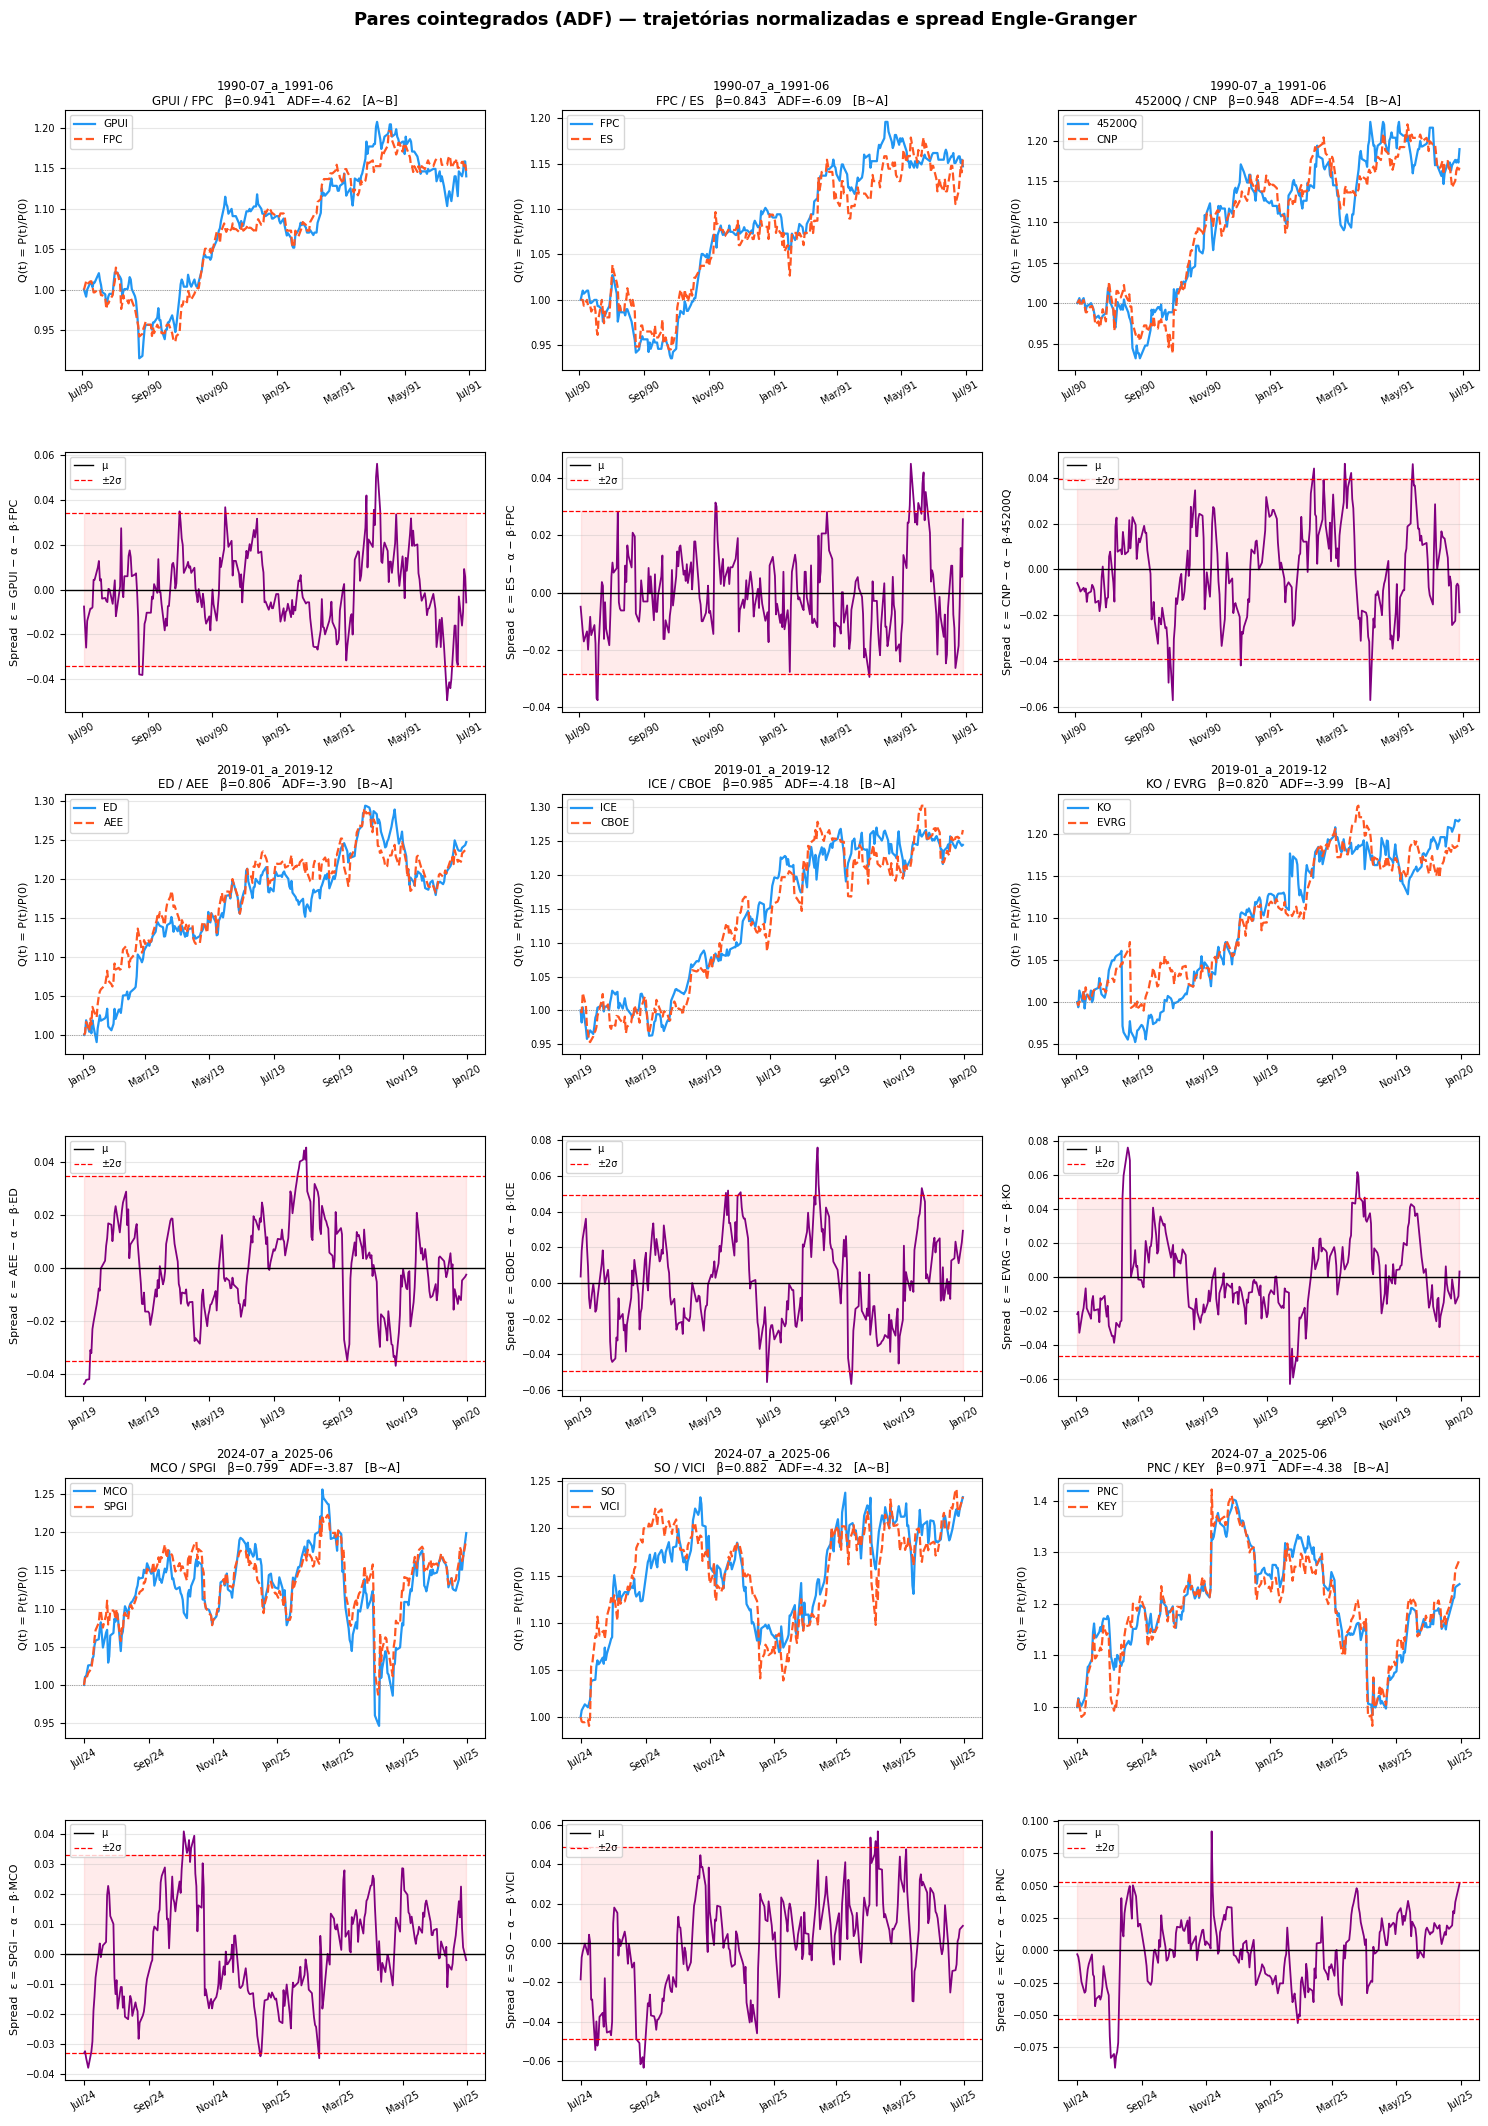

Salvo em: output/pares_coint_visualizacao.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Janelas a visualizar — ajuste conforme quiser
JANELAS_ALVO = [
    pares_df['janela'].iloc[0],                                   # primeira janela
    pares_df[pares_df['formacao_inicio'].str.startswith('2019')]['janela'].iloc[0],  # COVID
    pares_df['janela'].iloc[-1],                                   # última janela
]
N_PARES = 3

n_rows = len(JANELAS_ALVO) * 2
fig, axes = plt.subplots(n_rows, N_PARES, figsize=(5 * N_PARES, 3.5 * n_rows))
fig.suptitle(
    f"Pares cointegrados ({METODO_COINT}) — trajetórias normalizadas e spread Engle-Granger",
    fontsize=13, fontweight='bold', y=1.01,
)

CORES = ['#2196F3', '#FF5722']

for bloco, janela_id in enumerate(JANELAS_ALVO):
    row_q = bloco * 2
    row_s = bloco * 2 + 1

    pares_janela = pares_df[pares_df['janela'] == janela_id].head(N_PARES)
    if pares_janela.empty:
        continue

    # Recorta dados da janela de formação
    form_inicio = pd.Period(pares_janela.iloc[0]['formacao_inicio'], freq='M')
    form_fim    = pd.Period(pares_janela.iloc[0]['formacao_fim'],    freq='M')
    meses_form  = [m for m in meses_unicos if form_inicio <= m <= form_fim]
    mask        = meses_por_linha.isin(meses_form)
    precos      = filtrar_ativos_completos(df.loc[mask, colunas_preco])
    Q           = normalizar_precos(precos)

    for col, (_, par) in enumerate(pares_janela.iterrows()):
        a1, a2 = par['ativo1'], par['ativo2']
        beta   = par['beta']
        alpha  = par['alpha']
        mu     = par['spread_media']
        sigma  = par['spread_desvio']
        direcao = par.get('direcao', 'B~A')

        if a1 not in Q.columns or a2 not in Q.columns:
            for ax in [axes[row_q, col], axes[row_s, col]]:
                ax.axis('off')
            continue

        # Variável dependente (y) e independente (x) conforme a direção salva
        if direcao == 'A~B':
            dep, indep = a1, a2
        else:                       # 'B~A' (orientação original)
            dep, indep = a2, a1

        ax_q = axes[row_q, col]
        ax_s = axes[row_s, col]

        # Painel superior: Q1(t) e Q2(t)
        ax_q.plot(Q.index, Q[a1], color=CORES[0], lw=1.6, label=a1)
        ax_q.plot(Q.index, Q[a2], color=CORES[1], lw=1.6, ls='--', label=a2)
        ax_q.axhline(1, color='gray', lw=0.6, ls=':')
        ax_q.set_title(
            f"{janela_id}\n{a1} / {a2}   β={beta:.3f}   {par['metodo']}={par['stat']:.2f}   [{direcao}]",
            fontsize=8.5, pad=4,
        )
        ax_q.set_ylabel('Q(t) = P(t)/P(0)', fontsize=8)
        ax_q.legend(fontsize=7.5, loc='upper left')
        ax_q.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
        ax_q.tick_params(axis='x', rotation=30, labelsize=7)
        ax_q.tick_params(axis='y', labelsize=7)
        ax_q.grid(axis='y', alpha=0.3)

        # Painel inferior: resíduo do OLS = Q_dep - alpha - beta * Q_indep
        spread = Q[dep] - alpha - beta * Q[indep]
        ax_s.plot(spread.index, spread, color='purple', lw=1.3)
        ax_s.axhline(mu,             color='black', lw=1.0, ls='-',  label='μ')
        ax_s.axhline(mu + 2 * sigma, color='red',   lw=0.9, ls='--', label='±2σ')
        ax_s.axhline(mu - 2 * sigma, color='red',   lw=0.9, ls='--')
        ax_s.fill_between(spread.index, mu - 2 * sigma, mu + 2 * sigma,
                          alpha=0.08, color='red')
        ax_s.set_ylabel(f'Spread  ε = {dep} − α − β·{indep}', fontsize=8)
        ax_s.legend(fontsize=7, loc='upper left')
        ax_s.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
        ax_s.tick_params(axis='x', rotation=30, labelsize=7)
        ax_s.tick_params(axis='y', labelsize=7)
        ax_s.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/pares_coint_visualizacao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvo em: output/pares_coint_visualizacao.png")